In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

all_dfs = []

# Parameters
E=1
rho=2
L=1

Nt=300
Nx=100
SS=5
Ntot = Nx + 2*SS

nodes = np.arange(SS, Ntot-SS)  

t_end=3
dt=t_end/Nt
dx = L / (Nx - 1)
CFL = dt/dx * np.sqrt(E/rho)

ndt = 1

N=6
LAG_LABELS = {0: "t", 1: "t-dt", 2: "t-2dt"}
def jlabel(k):
    return "j" if k == 0 else f"j{k:+d}"

AMPLITUDES = np.linspace(0.005, 0.1, N).round(3).tolist()
PULSATIONS = np.linspace(1, 10, N).round(1).tolist()
n_sims = len(AMPLITUDES)*len(PULSATIONS)

# We compute each simulation
all_dfs = []

for idx, (A, omega) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):

    t_pulse = 2 * np.pi / omega
    def u_right(t):
        return A * np.sin(omega * t) if t < t_pulse else 0.0

    u    = np.zeros(Ntot)
    u_1  = np.zeros(Ntot)
    u_xx = np.zeros(Ntot)

    u_storage    = np.zeros((Nt + 1, Ntot))
    u_xx_storage = np.zeros((Nt,     Ntot))
    u_storage[0] = u.copy()

    i_left  = SS
    i_right = Ntot - SS

    # --- Boucle de simulation sur la grille étendue ---
    for n in range(Nt):
        t = n * dt
        u_xx[i_left:i_right+1] = (u[i_left-1:i_right] - 2*u[i_left:i_right+1] + u[i_left+1:i_right+2]) / dx**2

        u_new = np.zeros(Ntot)
        u_new[i_left:i_right+1] = (2.0 * u[i_left:i_right+1] - u_1[i_left:i_right+1] + CFL**2 * (u[i_left-1:i_right] - 2.0 * u[i_left:i_right+1] + u[i_left+1:i_right+2]))
        u_new[:i_left+1] = 0.0              
        u_new[i_right:]  = u_right(t + dt) 

        u_xx_storage[n] = u_xx
        u_1 = u.copy()
        u   = u_new
        u_storage[n + 1] = u.copy()

    # --- Construction du dataset : 3 niveaux temporels, voisinage ±SS ---
    rows = []
    for n in range(3*ndt, Nt - ndt + 1):
        row = {"A": A, "omega": omega, "n_step": n}

        for lvl in (0, 1, 2):                                
            m    = n - lvl * ndt                            
            tlab = LAG_LABELS[lvl]
            udot_m = (u_storage[m] - u_storage[m - ndt]) / (ndt * dt)   # u_dot au pas m
            for k in range(-SS, SS + 1):                     
                row[f"u_dot({tlab},{jlabel(k)})"] = udot_m[nodes + k]
                row[f"u_xx({tlab},{jlabel(k)})"]  = u_xx_storage[m, nodes + k]

        row["delta_u@ndt"] = u_storage[n + ndt, nodes] - u_storage[n, nodes]
        rows.append(pd.DataFrame(row))

    all_dfs.append(pd.concat(rows, ignore_index=True))

df = pd.concat(all_dfs, ignore_index=True)
print(df.head(0))
print(f"{len(df):,} lignes × {df.shape[1]} colonnes")


Empty DataFrame
Columns: [A, omega, n_step, u_dot(t,j-5), u_xx(t,j-5), u_dot(t,j-4), u_xx(t,j-4), u_dot(t,j-3), u_xx(t,j-3), u_dot(t,j-2), u_xx(t,j-2), u_dot(t,j-1), u_xx(t,j-1), u_dot(t,j), u_xx(t,j), u_dot(t,j+1), u_xx(t,j+1), u_dot(t,j+2), u_xx(t,j+2), u_dot(t,j+3), u_xx(t,j+3), u_dot(t,j+4), u_xx(t,j+4), u_dot(t,j+5), u_xx(t,j+5), u_dot(t-dt,j-5), u_xx(t-dt,j-5), u_dot(t-dt,j-4), u_xx(t-dt,j-4), u_dot(t-dt,j-3), u_xx(t-dt,j-3), u_dot(t-dt,j-2), u_xx(t-dt,j-2), u_dot(t-dt,j-1), u_xx(t-dt,j-1), u_dot(t-dt,j), u_xx(t-dt,j), u_dot(t-dt,j+1), u_xx(t-dt,j+1), u_dot(t-dt,j+2), u_xx(t-dt,j+2), u_dot(t-dt,j+3), u_xx(t-dt,j+3), u_dot(t-dt,j+4), u_xx(t-dt,j+4), u_dot(t-dt,j+5), u_xx(t-dt,j+5), u_dot(t-2dt,j-5), u_xx(t-2dt,j-5), u_dot(t-2dt,j-4), u_xx(t-2dt,j-4), u_dot(t-2dt,j-3), u_xx(t-2dt,j-3), u_dot(t-2dt,j-2), u_xx(t-2dt,j-2), u_dot(t-2dt,j-1), u_xx(t-2dt,j-1), u_dot(t-2dt,j), u_xx(t-2dt,j), u_dot(t-2dt,j+1), u_xx(t-2dt,j+1), u_dot(t-2dt,j+2), u_xx(t-2dt,j+2), u_dot(t-2dt,j+3), u_xx(t-2dt

## Split train and val 

In [2]:
rng = np.random.default_rng(seed=42)

n_rows = len(df)
n_train = int(0.60 * n_rows)
n_val   = int(0.20 * n_rows)
n_test  = n_rows - n_train - n_val

# 1. On crée un grand tableau contenant la proportion exacte de chaque étiquette
split_labels = np.array(["train"] * n_train + ["val"] * n_val + ["test"] * n_test)

# 2. On le mélange de manière purement aléatoire
rng.shuffle(split_labels)

# 3. On l'assigne directement à la colonne du DataFrame
df["split"] = split_labels

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")

Distribution du split :
  train :  641,520 lignes  (60.0 %)
  val   :  213,840 lignes  (20.0 %)
  test  :  213,840 lignes  (20.0 %)


In [3]:
INPUTS = ["u_dot(t,j)","u_dot(t-dt,j)","u_dot(t-2dt,j)","u_xx(t,j)","u_xx(t-dt,j)","u_xx(t-2dt,j)","u_dot(t,j-1)","u_dot(t-dt,j-1)","u_dot(t-2dt,j-1)","u_xx(t,j-1)","u_xx(t-dt,j-1)","u_xx(t-2dt,j-1)","u_dot(t,j+1)","u_dot(t-dt,j+1)","u_dot(t-2dt,j+1)","u_xx(t,j+1)","u_xx(t-dt,j+1)","u_xx(t-2dt,j+1)","u_xx(t,j-2)","u_xx(t,j+2)"]
OUTPUTS = ["delta_u@ndt"]

# Masque train pour calculer les stats uniquement sur le train set
train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

import json

params_simulation = {
    "L"          : L,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "E": E,
    "rho":rho,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
    "INPUTS":INPUTS,
    "OUTPUTS":OUTPUTS,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")



Statistiques de normalisation (calculées sur train) :
                      mean       std
u_dot(t,j)       -0.000893  0.191581
u_dot(t-dt,j)    -0.001074  0.191257
u_dot(t-2dt,j)   -0.001262  0.190989
u_xx(t,j)         0.033111  7.302459
u_xx(t-dt,j)      0.040540  7.296033
u_xx(t-2dt,j)     0.042757  7.281613
u_dot(t,j-1)     -0.000895  0.190997
u_dot(t-dt,j-1)  -0.001078  0.190665
u_dot(t-2dt,j-1) -0.001251  0.190277
u_xx(t,j-1)       0.034294  7.291800
u_xx(t-dt,j-1)    0.036409  7.279513
u_xx(t-2dt,j-1)   0.034635  7.273313
u_dot(t,j+1)     -0.000968  0.192258
u_dot(t-dt,j+1)  -0.001092  0.191887
u_dot(t-2dt,j+1) -0.001217  0.191539
u_xx(t,j+1)      -0.003779  6.710981
u_xx(t-dt,j+1)   -0.006532  6.714577
u_xx(t-2dt,j+1)  -0.006098  6.714952
u_xx(t,j-2)       0.036962  7.255550
u_xx(t,j+2)       0.001687  6.657296
delta_u@ndt      -0.000007  0.001920
Dataset sauvegardé : wave_beam_dataset.csv
  1,069,200 lignes × 43 colonnes
Stats de normalisation sauvegardées : norm_stats.csv
Par

In [4]:
import numpy as np
import json

with open("params_simulation.json") as f:
    p = json.load(f)

L, Nx, Nt,t_end  = p["L"], p["Nx"], p["Nt"], p["t_end"]
AMPLITUDES    = p["AMPLITUDES"]
PULSATIONS    = p["PULSATIONS"]
n_sims        = p["n_sims"]
E   = p["E"]
rho = p["rho"]
v   = np.sqrt(E / rho)
INPUTS=p["INPUTS"]
OUTPUTS=p["OUTPUTS"]

# Fichiers produits par le notebook 01
DATASET_FILE   = "wave_beam_dataset.csv"
NORMSTATS_FILE = "norm_stats.csv"

# Architecture du réseau
HIDDEN_SIZES = [256, 128, 64]    # nombre de neurones par couche cachée

# Entraînement
LEARNING_RATE = 1e-3
N_EPOCHS      = 25
BATCH_SIZE    = 512



In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Chargement du dataset et des stats de normalisation
df         = pd.read_csv(DATASET_FILE)
norm_stats = pd.read_csv(NORMSTATS_FILE, index_col=0)

#To check and visualise
print(f"Dataset : {len(df):,} lignes")
print(f"Splits  : {df['split'].value_counts().to_dict()}")

# Colonnes normalisées
INPUTS_N = [f"{x}_n" for x in INPUTS]
OUTPUTS_N = [f"{x}_n" for x in OUTPUTS]

# Extraction train / val / test en utilisant la colonne split du dataset
train_mask = df["split"] == "train"
val_mask   = df["split"] == "val"
test_mask  = df["split"] == "test"  # <-- AJOUTÉ

X_train = df.loc[train_mask, INPUTS_N].values.astype(np.float32)
y_train = df.loc[train_mask, OUTPUTS_N].values.astype(np.float32)

X_val   = df.loc[val_mask, INPUTS_N].values.astype(np.float32)
y_val   = df.loc[val_mask, OUTPUTS_N].values.astype(np.float32)

X_test  = df.loc[test_mask, INPUTS_N].values.astype(np.float32)  # <-- AJOUTÉ
y_test  = df.loc[test_mask, OUTPUTS_N].values.astype(np.float32)  # <-- AJOUTÉ

print(f"\nTrain : {len(X_train):,} exemples")
print(f"Val   : {len(X_val):,} exemples")
print(f"Test  : {len(X_test):,} exemples")  # <-- AJOUTÉ

# Conversion en tenseurs PyTorch et création des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE
)
test_loader = DataLoader(  # <-- AJOUTÉ
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=BATCH_SIZE, shuffle=False
)

Dataset : 1,069,200 lignes
Splits  : {'train': 641520, 'val': 213840, 'test': 213840}

Train : 641,520 exemples
Val   : 213,840 exemples
Test  : 213,840 exemples


In [6]:
class Reseau(nn.Module):

    def __init__(self, n_inputs, n_outputs, hidden_sizes):
        super().__init__()

        couches = []
        taille_entree = n_inputs

        for taille in hidden_sizes:
            couches.append(nn.Linear(taille_entree, taille))  # couche linéaire
            couches.append(nn.Tanh())                              # activation non-linéaire
            taille_entree = taille

        couches.append(nn.Linear(taille_entree, n_outputs))  # couche de sortie
        self.reseau = nn.Sequential(*couches)

    def forward(self, x):
        return self.reseau(x)


modele = Reseau(
    n_inputs    = len(INPUTS_N), 
    n_outputs   = len(OUTPUTS_N),   
    hidden_sizes = HIDDEN_SIZES,
)

n_params = sum(p.numel() for p in modele.parameters())
print(modele)
print(f"\nNombre de paramètres : {n_params:,}")



Reseau(
  (reseau): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Nombre de paramètres : 46,593


Epoch    2/25  —  train: 0.0013  |  val: 0.0011  
Epoch    4/25  —  train: 0.0008  |  val: 0.0015  
Epoch    6/25  —  train: 0.0008  |  val: 0.0008  
Epoch    8/25  —  train: 0.0006  |  val: 0.0003  
Epoch   10/25  —  train: 0.0007  |  val: 0.0009  
Epoch   12/25  —  train: 0.0007  |  val: 0.0002  
Epoch   14/25  —  train: 0.0004  |  val: 0.0004  
Epoch   16/25  —  train: 0.0004  |  val: 0.0017  
Epoch   18/25  —  train: 0.0006  |  val: 0.0005  
Epoch   20/25  —  train: 0.0011  |  val: 0.0003  
Epoch   22/25  —  train: 0.0006  |  val: 0.0012  
Epoch   24/25  —  train: 0.0001  |  val: 0.0002  


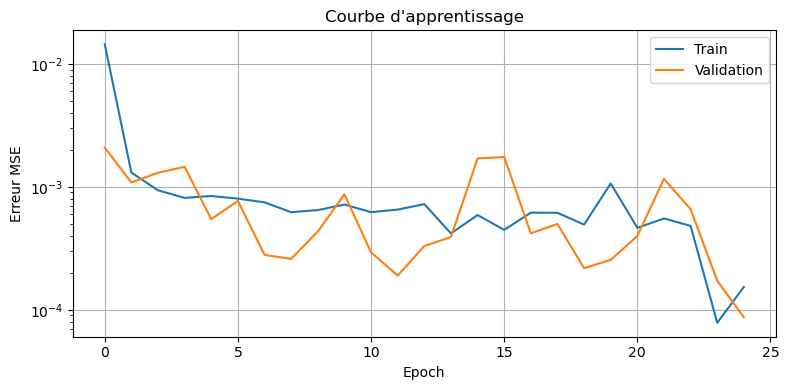

Meilleur modèle rechargé — val minimale : 0.000087


In [7]:
criterion  = nn.MSELoss() 

optimiseur = torch.optim.Adam(modele.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiseur, mode="min", factor=0.5, patience=10
)

historique_train = []
historique_val   = []

meilleure_val = float("inf")   # on initialise au pire score possible
patience_compteur = 0          # on verra ça après

for epoch in range(1, N_EPOCHS + 1):

    # Phase entraînement
    modele.train()
    perte_train = 0.0       #initialisation of training loss
    for X_batch, y_batch in train_loader:
        
        optimiseur.zero_grad()                       # remet les gradients à zéro

        prediction = modele(X_batch)                 # prédiction

        perte      = criterion(prediction, y_batch)  # erreur

        perte.backward()                             # rétropropagation

        optimiseur.step()                            # mise à jour des poids
        
        perte_train += perte.item()
    perte_train /= len(train_loader)

    # Phase validation : un seul forward pass sur tout le val
    modele.eval()
    with torch.no_grad():
        pred_val = modele(torch.tensor(X_val)).numpy()

    # Loss globale 
    perte_val = ((pred_val - y_val)**2).mean()
    scheduler.step(perte_val)

    # Loss par output
    historique_train.append(perte_train)
    historique_val  .append(perte_val)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:4d}/{N_EPOCHS}  —  "
            f"train: {perte_train:.4f}  |  "
            f"val: {perte_val:.4f}  ")
    
    # Si la val s'est améliorée, on sauvegarde ce modèle
    if perte_val < meilleure_val:
        meilleure_val = perte_val
        torch.save(modele.state_dict(), "model.pth")   # on écrase avec le meilleur

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(historique_train, label="Train")
ax.plot(historique_val,   label="Validation")
ax.set_xlabel("Epoch") ; ax.set_ylabel("Erreur MSE")
ax.set_title("Courbe d'apprentissage")
ax.set_yscale("log")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# On recharge le meilleur modèle trouvé pendant l'entraînement
modele.load_state_dict(torch.load("model.pth",weights_only=True ))
print(f"Meilleur modèle rechargé — val minimale : {meilleure_val:.6f}")



## Pushforward trick

Ré-entraînement du modèle avec le **pushforward trick** (Brandstetter et al., ICLR 2022).

Principe : au lieu d'utiliser toujours l'état GT en entrée, on unrolle le solver 2 pas, mais on ne backpropage que sur le **dernier** pas. L'état intermédiaire (résultat du 1er pas sans gradient) sert de perturbation adversariale, ce qui force le modèle à être robuste aux erreurs accumulées pendant le rollout.

```
X_1 = features(U_GT[n])
U_pushed[n+1] = U_GT[n] + model(X_1)     ← sans gradient (stop_grad)
X_2 = features(U_pushed[n+1])
loss = MSE(model(X_2), delta_GT[n+1→n+2]) ← gradient ici seulement
```

In [8]:
# ================================================================
# PUSHFORWARD — Setup : fonctions utilitaires + pré-génération
# ================================================================

from itertools import product as iproduct

# ---- Constantes géométriques (identiques au notebook de génération) ----
SS_pf    = 5
Ntot_pf  = Nx + 2 * SS_pf
i_left   = SS_pf
i_right  = Ntot_pf - SS_pf
nodes_pf = np.arange(i_left, i_right)   # 100 nœuds intérieurs

mu_delta = norm_stats.loc["delta_u@ndt", "mean"]
sd_delta = norm_stats.loc["delta_u@ndt", "std"]

# ---- Décodage des noms de colonnes ----
def _parse_feature(name):
    field, rest = name.replace("@", "").split("(")
    time_lab, space_lab = rest.rstrip(")").split(",")
    k   = {"t": 0, "t-dt": 1, "t-2dt": 2}[time_lab]
    off = {"j": 0, "j-1": -1, "j+1": +1, "j-2": -2, "j+2": +2}[space_lab]
    return field, k, off

SPEC_pf = [_parse_feature(c) for c in INPUTS]

# ---- u_xx sur grille étendue ----
def _u_xx_ext(u_arr):
    out = np.zeros(Ntot_pf)
    out[i_left:i_right+1] = (
        u_arr[i_left-1:i_right] - 2*u_arr[i_left:i_right+1] + u_arr[i_left+1:i_right+2]
    ) / dx**2
    return out

# ---- Construction de la matrice de features normalisée ----
def _features_at(u_cur, u_prev, u_prev2, u_prev3):
    """
    Retourne X de shape (n_nodes, n_inputs), normalisé.

    u_cur   : état à l'instant t   (array Ntot)
    u_prev  : état à t - ndt
    u_prev2 : état à t - 2*ndt
    u_prev3 : état à t - 3*ndt
    """
    udot = [
        (u_cur   - u_prev)  / (ndt * dt),
        (u_prev  - u_prev2) / (ndt * dt),
        (u_prev2 - u_prev3) / (ndt * dt),
    ]
    uxx = [_u_xx_ext(u_cur), _u_xx_ext(u_prev), _u_xx_ext(u_prev2)]

    X = np.zeros((len(nodes_pf), len(INPUTS)), dtype=np.float32)
    for i, (name, (field, k, off)) in enumerate(zip(INPUTS, SPEC_pf)):
        base = udot[k] if field == "u_dot" else uxx[k]
        X[:, i] = (base[nodes_pf + off] - norm_stats.loc[name, "mean"]) / norm_stats.loc[name, "std"]
    return X

# ---- Biais au repos (prédiction du modèle pour l'état zéro) ----
Xz = np.zeros((len(nodes_pf), len(INPUTS)), dtype=np.float32)
for i, name in enumerate(INPUTS):
    Xz[:, i] = (0.0 - norm_stats.loc[name, "mean"]) / norm_stats.loc[name, "std"]

modele.eval()
with torch.no_grad():
    biais_repos = float((modele(torch.tensor(Xz)).numpy() * sd_delta + mu_delta)[0, 0])
print(f"Biais au repos : {biais_repos:.3e}")

# ---- Simulation numérique ----
def _simulate(A, omega):
    t_pulse = 2 * np.pi / omega
    u, u_1  = np.zeros(Ntot_pf), np.zeros(Ntot_pf)
    U       = np.zeros((Nt + 1, Ntot_pf))
    for n in range(Nt):
        t      = n * dt
        t_next = t + dt
        u_new  = np.zeros(Ntot_pf)
        u_new[i_left:i_right+1] = (
            2*u[i_left:i_right+1] - u_1[i_left:i_right+1]
            + CFL**2 * (u[i_left-1:i_right] - 2*u[i_left:i_right+1] + u[i_left+1:i_right+2])
        )
        u_new[:i_left+1] = 0.0
        u_new[i_right:]  = A * np.sin(omega * t_next) if t_next < t_pulse else 0.0
        u_1, u = u.copy(), u_new
        U[n + 1] = u.copy()
    return U

# ---- Pré-génération de toutes les trajectoires ----
print("Génération des trajectoires...", end=" ", flush=True)
all_trajs = {
    (A, omega): _simulate(A, omega)
    for A, omega in iproduct(AMPLITUDES, PULSATIONS)
}
print(f"OK — {len(all_trajs)} trajectoires, shape {next(iter(all_trajs.values())).shape}")

Biais au repos : -3.664e-06
Génération des trajectoires... OK — 36 trajectoires, shape (301, 110)


Epoch   1/20  train: 0.00025  val: 0.00008
Epoch   2/20  train: 0.00011  val: 0.00018
Epoch   3/20  train: 0.00021  val: 0.00018
Epoch   4/20  train: 0.00018  val: 0.00018
Epoch   5/20  train: 0.00012  val: 0.00014
Epoch   6/20  train: 0.00014  val: 0.00023
Epoch   7/20  train: 0.00014  val: 0.00018
Epoch   8/20  train: 0.00009  val: 0.00022
Epoch   9/20  train: 0.00009  val: 0.00021
Epoch  10/20  train: 0.00011  val: 0.00028
Epoch  11/20  train: 0.00012  val: 0.00024
Epoch  12/20  train: 0.00010  val: 0.00030
Epoch  13/20  train: 0.00011  val: 0.00024
Epoch  14/20  train: 0.00009  val: 0.00031
Epoch  15/20  train: 0.00010  val: 0.00028
Epoch  16/20  train: 0.00010  val: 0.00036
Epoch  17/20  train: 0.00010  val: 0.00032
Epoch  18/20  train: 0.00010  val: 0.00039
Epoch  19/20  train: 0.00010  val: 0.00036
Epoch  20/20  train: 0.00011  val: 0.00045


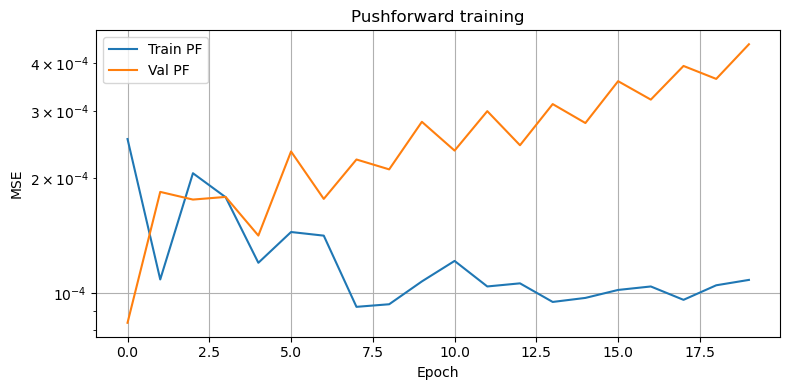

Meilleur modèle PF rechargé — val: 0.000084


In [9]:
# ================================================================
# PUSHFORWARD — Boucle d'entraînement
# ================================================================

N_EPOCHS_PF    = 20
LR_PF          = 5e-4
BATCH_SIZE_PF  = 1024
SAMPLES_PER_SIM = 40   # instants de départ tirés par simulation et par epoch

# Partir du meilleur modèle one-step (fine-tuning)
modele.load_state_dict(torch.load("model.pth", weights_only=True))

opt_pf   = torch.optim.Adam(modele.parameters(), lr=LR_PF)
sched_pf = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_pf, mode="min", factor=0.5, patience=5)
crit_pf  = nn.MSELoss()

hist_train_pf, hist_val_pf = [], []
best_val_pf = float("inf")

# Besoin de 3*ndt états GT en arrière + 2*ndt états GT en avant
HISTORY = 3 * ndt

for epoch in range(1, N_EPOCHS_PF + 1):

    # ----------------------------------------------------------
    # Phase 1 – construire le dataset pushforward (sans gradient)
    # ----------------------------------------------------------
    all_X2, all_tgt = [], []

    modele.eval()
    with torch.no_grad():
        for (A, omega), U in all_trajs.items():

            valid_ns = np.arange(HISTORY, Nt - 2 * ndt)
            chosen   = np.random.choice(valid_ns, size=SAMPLES_PER_SIM, replace=False)

            for n in chosen:
                u3 = U[n - 3*ndt]
                u2 = U[n - 2*ndt]
                u1 = U[n -   ndt]
                u0 = U[n]

                # Pas sans gradient : features GT à l'instant n → delta prédit
                X1          = _features_at(u0, u1, u2, u3)
                delta1_norm = modele(torch.tensor(X1)).numpy()[:, 0]
                delta1_phys = delta1_norm * sd_delta + mu_delta - biais_repos

                # État poussé à n+ndt : nœuds intérieurs = GT + delta prédit
                # Les BCs sont copiées depuis la GT (déjà correctes)
                u_pushed = U[n + ndt].copy()
                u_pushed[nodes_pf] = u0[nodes_pf] + delta1_phys

                # Features à n+ndt depuis l'état poussé
                X2 = _features_at(u_pushed, u0, u1, u2)

                # Cible : delta GT de n+ndt à n+2*ndt, normalisé
                delta_true = U[n + 2*ndt, nodes_pf] - U[n + ndt, nodes_pf]
                tgt        = (delta_true - mu_delta) / sd_delta

                all_X2.append(X2)
                all_tgt.append(tgt[:, None])

    X2_all = torch.tensor(np.concatenate(all_X2, axis=0), dtype=torch.float32)
    T_all  = torch.tensor(np.concatenate(all_tgt, axis=0), dtype=torch.float32)

    # ----------------------------------------------------------
    # Phase 2 – mini-batch gradient descent sur ce dataset
    # ----------------------------------------------------------
    modele.train()
    perm   = torch.randperm(len(X2_all))
    X2_all = X2_all[perm]
    T_all  = T_all [perm]

    epoch_loss, n_batches = 0.0, 0
    for i in range(0, len(X2_all), BATCH_SIZE_PF):
        X_b = X2_all[i : i + BATCH_SIZE_PF]
        T_b = T_all [i : i + BATCH_SIZE_PF]
        opt_pf.zero_grad()
        loss = crit_pf(modele(X_b), T_b)
        loss.backward()
        opt_pf.step()
        epoch_loss += loss.item()
        n_batches  += 1
    epoch_loss /= n_batches

    # ----------------------------------------------------------
    # Validation sur le val set statique
    # ----------------------------------------------------------
    modele.eval()
    with torch.no_grad():
        pred_val = modele(torch.tensor(X_val)).numpy()
    val_loss = float(((pred_val - y_val)**2).mean())

    sched_pf.step(val_loss)
    hist_train_pf.append(epoch_loss)
    hist_val_pf  .append(val_loss)

    if val_loss < best_val_pf:
        best_val_pf = val_loss
        torch.save(modele.state_dict(), "model_pf.pth")

    print(f"Epoch {epoch:3d}/{N_EPOCHS_PF}  train: {epoch_loss:.5f}  val: {val_loss:.5f}")

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_train_pf, label="Train PF")
ax.plot(hist_val_pf,   label="Val PF")
ax.set_yscale("log")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.set_title("Pushforward training")
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

modele.load_state_dict(torch.load("model_pf.pth", weights_only=True))
print(f"Meilleur modèle PF rechargé — val: {best_val_pf:.6f}")

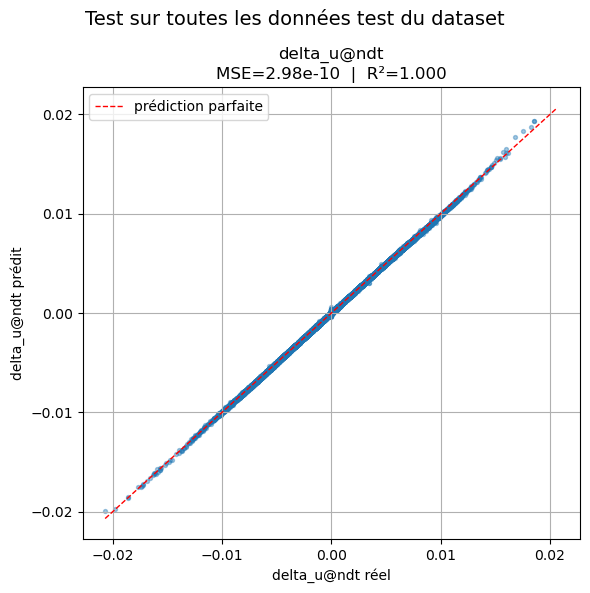

delta_u@ndt     : MSE = 2.9824e-10  |  R² = 0.9999


In [10]:
# --- 1. Choisir des paramètres ---
df_test=df[df["split"]=="test"].reset_index(drop=True)

X_new  = df_test[[c + "_n" for c in INPUTS]].values.astype(np.float32)
y_true = df_test[OUTPUTS].values   # shape (N, 3)

# --- 4. Prédiction ---
modele.eval()
with torch.no_grad():
    y_pred_n = modele(torch.tensor(X_new)).numpy()   # shape (N, 3)

# Dénormalisation colonne par colonne
y_pred = np.zeros_like(y_pred_n)
for i, col in enumerate(OUTPUTS):
    mean_du = norm_stats.loc[col, "mean"]
    std_du  = norm_stats.loc[col, "std"]
    y_pred[:, i] = y_pred_n[:, i] * std_du + mean_du

# --- 5. Visualisation : une figure par sortie ---
fig, axes = plt.subplots(1, len(OUTPUTS), figsize=(6*len(OUTPUTS), 6), squeeze=False)
axes = axes.flatten()

#fig, axes = plt.subplots(1, len(OUTPUTS), figsize=(6*len(OUTPUTS), 6))

for i, (ax, col) in enumerate(zip(axes, OUTPUTS)):
    y_r = y_true[:, i]
    y_p = y_pred[:, i]
    
    ax.scatter(y_r, y_p, alpha=0.4, s=8)
    lim = max(abs(y_r).max(), abs(y_p).max())
    ax.plot([-lim, lim], [-lim, lim], "r--", lw=1, label="prédiction parfaite")
    
    ax.set_xlabel(f"{col} réel")
    ax.set_ylabel(f"{col} prédit")
    
    mse = ((y_p - y_r)**2).mean()
    r2  = 1 - mse / y_r.var()
    ax.set_title(f"{col}\nMSE={mse:.2e}  |  R²={r2:.3f}")
    ax.legend()
    ax.grid(True)

fig.suptitle("Test sur toutes les données test du dataset", fontsize=14)
plt.tight_layout()
plt.show()

# --- 6. Métriques globales ---
for i, col in enumerate(OUTPUTS):
    mse = ((y_pred[:,i] - y_true[:,i])**2).mean()
    r2  = 1 - mse / y_true[:,i].var()
    print(f"{col:15s} : MSE = {mse:.4e}  |  R² = {r2:.4f}")

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000

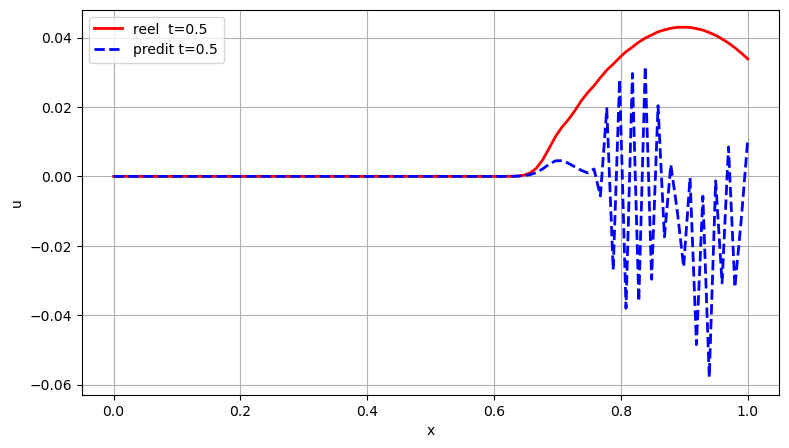

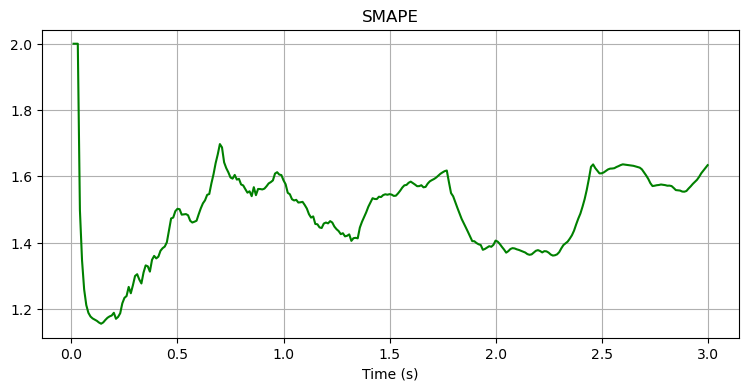

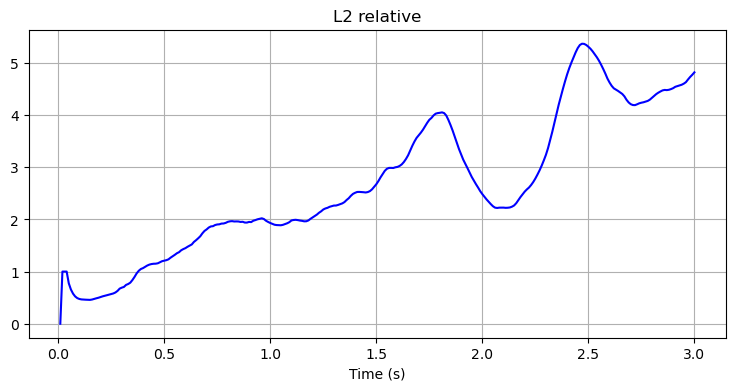

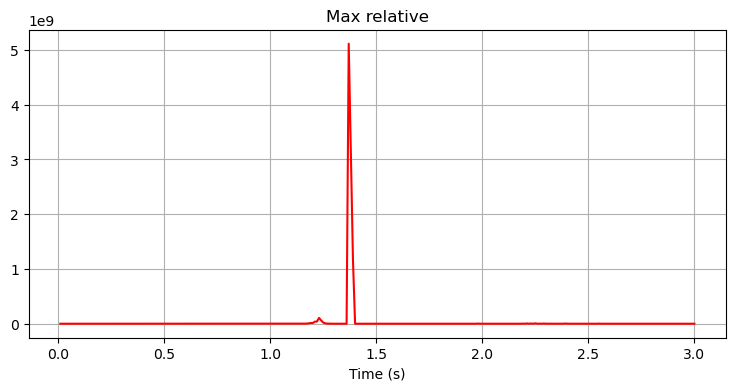

In [11]:
# Roll out cell  (avance par paquets de 3 pas)
import time

A, omega = AMPLITUDES[2], PULSATIONS[2]
dx = L / (Nx - 1)
dt = t_end / Nt
CFL = v * dt / dx
x = np.linspace(0, L, Nx)
t_list = [0.5]

t_pulse = 2 * np.pi / omega

def u_right(t):
    if t < t_pulse:
        return A * np.sin(omega * t)
    else:
        return 0.0

def u_xx_de(uu):
    out = np.zeros(Nx)
    out[1:-1] = (uu[2:] - 2*uu[1:-1] + uu[:-2]) / dx**2
    return out

def shift_clamp(a, dk):                
    idx = np.clip(np.arange(Nx) + dk, 0, Nx - 1)
    return a[idx]

# Décodage automatique des noms de colonnes : "u_xx(t-dt,j+1)" -> ("u_xx", 1, +1)
def parse_feature(name):
    field, rest = name.replace("@", "").split("(")
    time_lab, space_lab = rest.rstrip(")").split(",")
    k   = {"t": 0, "t-dt": 1, "t-2dt": 2}[time_lab]
    off = {"j": 0, "j-1": -1, "j+1": +1, "j-2": -2, "j+2": +2}[space_lab]
    return field, k, off

SPEC  = [parse_feature(c) for c in INPUTS]  

i_left, i_right = SS, Ntot - SS
nodes = np.arange(i_left, i_right) 
mu = norm_stats.loc[OUTPUTS, "mean"].values    
sd = norm_stats.loc[OUTPUTS, "std"].values   

def u_xx_etendu(u):                    # u_xx sur la grille étendue (longueur Ntot)
    u_xx = np.zeros(Ntot)
    u_xx[i_left:i_right+1] = (u[i_left-1:i_right] - 2*u[i_left:i_right+1] + u[i_left+1:i_right+2]) / dx**2
    return u_xx

# =====================================================
# 1) VRAIE simulation
# =====================================================

t0 = time.perf_counter()

U_reel = np.zeros((Nt + 1, Ntot))
u, u_1 = np.zeros(Ntot), np.zeros(Ntot)

for n in range(Nt):
    t = n * dt
    u_new = np.zeros(Ntot)
    u_new[i_left:i_right+1] = (2*u[i_left:i_right+1] - u_1[i_left:i_right+1] + CFL**2 * (u[i_left-1:i_right] - 2*u[i_left:i_right+1] + u[i_left+1:i_right+2]))
    u_new[:i_left+1] = 0.0
    u_new[i_right:]  = u_right(t + dt)
    u_1, u = u.copy(), u_new
    U_reel[n + 1] = u.copy()

time_phys = time.perf_counter() - t0

# =====================================================
# 2) Simulation PREDITE
# =====================================================

t0 = time.perf_counter()

history_needed = 3 * ndt

# Biais au repos (état nul) : principe inchangé
Xz = np.zeros((len(nodes), len(INPUTS)), dtype=np.float32)
for i, (name, (field, k, off)) in enumerate(zip(INPUTS, SPEC)):
    Xz[:, i] = (np.zeros(len(nodes)) - norm_stats.loc[name, "mean"]) / norm_stats.loc[name, "std"]

with torch.no_grad():
    biais_repos = (modele(torch.tensor(Xz)).numpy() * sd + mu)[0, 0]

U = np.zeros((Nt + 1 + history_needed, Ntot))

u_tt_dict = {}
u_xx_dict = {}

uxx_0 = np.zeros(Ntot)
uxx_1 = np.zeros(Ntot)
uxx_2 = np.zeros(Ntot)

for n in range(history_needed, Nt + history_needed - ndt + 1, ndt) :

    udot_0 = (U[n]  - U[n - ndt]) / (ndt*dt)
    udot_1 = (U[n   - 1*ndt]    - U[n - 2*ndt])  / (ndt*dt)
    udot_2 = (U[n   - 2*ndt]    - U[n - 3*ndt])  / (ndt*dt)

    udot = [udot_0, udot_1, udot_2]

    uxx_0 = u_xx_etendu(U[n])
    uxx_1 = u_xx_etendu(U[n - 1*ndt])
    uxx_2 = u_xx_etendu(U[n - 2*ndt])
    
    uxx = [uxx_0, uxx_1, uxx_2]

    t_actuel = round((n-history_needed) * dt, 5)
    u_tt_dict[t_actuel] = udot[0][nodes]
    u_xx_dict[t_actuel]  = uxx[0][nodes]

    X = np.zeros((len(nodes), len(INPUTS)), dtype=np.float32)
    for i, (name, (field, k, off)) in enumerate(zip(INPUTS, SPEC)):
        base = udot[k] if field == "u_dot" else uxx[k]
        X[:, i] = (base[nodes + off] - norm_stats.loc[name, "mean"]) / norm_stats.loc[name, "std"]

    with torch.no_grad():
        sortie = modele(torch.tensor(X)).numpy()
    deltas = sortie * sd + mu - biais_repos

    U[n + ndt, nodes]     = U[n, nodes] + deltas[:, 0]
    U[n + ndt , :i_left+1]    = 0.0            
    U[n + ndt , i_right:]     = u_right((n + ndt - history_needed) * dt)

time_pred = time.perf_counter() - t0

for i in range (4,5):
    print(U[i, nodes])
    print(U_reel[i+history_needed, nodes])

print("temps physique :", round(time_phys, 6))
print("temps predit   :", round(time_pred, 6))

m =  72 # multiple de ndt, dans la zone ou tu vois l'ecart
print("bord droit reel  :", U_reel[m, i_right:])
print("bord droit predit:", U[m + history_needed, i_right:])
print("interieur reel   :", U_reel[m, i_right-4:i_right])
print("interieur predit :", U[m + history_needed, i_right-4:i_right])

# =====================================================
# 3) Erreurs
# =====================================================

def l2_rel(pred, true, eps=1e-12):
    return np.linalg.norm(pred - true) / (np.linalg.norm(true) + eps)

def smape(pred, true):
    m = true != 0
    return np.mean(2*np.abs(true[m] - pred[m]) / (np.abs(true[m]) + np.abs(pred[m])))

def errormax(true, pred, eps=1e-12):
    return np.max(np.abs(true - pred) / (np.abs(true) + eps))

steps = np.arange(2*ndt, Nt + 1, ndt)

temps_sim    = np.array([(m + 1) * dt for m in range(Nt)])
error_mape   = np.array([smape   (U[m+1], U_reel[m+1]) for m in range(Nt)])
error_l2_rel = np.array([l2_rel  (U[m], U_reel[m]) for m in range(Nt)])
error_max    = np.array([errormax(U_reel[m+1], U[m+1]) for m in range(Nt)])

# =====================================================
# 4) Traces
# =====================================================

reel = {round(m*dt, 5): U_reel[m] for m in range(Nt + 1)}
pred = {round(m*dt, 5): U[m + history_needed] for m in range(Nt + 1)}

plt.figure(figsize=(9, 5))
for t in t_list:
    m = min(reel, key=lambda key: abs(key - t))
    plt.plot(x, reel[m][SS : Ntot-SS], "r",  lw=2, label=f"reel  t={t}")
    plt.plot(x, pred[m][SS : Ntot-SS], "b--", lw=2, label=f"predit t={t}")
plt.xlabel("x"); plt.ylabel("u"); plt.legend(); plt.grid(True)

for err, lab, c in [(error_mape, "SMAPE", "green"),
                    (error_l2_rel, "L2 relative", "blue"),
                    (error_max, "Max relative", "red")]:
    plt.figure(figsize=(9, 4))
    plt.plot(temps_sim, err, color=c, lw=1.5)
    plt.xlabel("Time (s)"); plt.title(lab); plt.grid(True)

# =====================================================
# 5) Visualisation u_xx en fonction de u_dot (prediction)
# =====================================================

# t_list_plot = [0.5, 0.8, 1, 1.5]
# colors = plt.cm.viridis(np.linspace(0, 1, len(t_list_plot)))

# plt.figure(figsize=(6, 6))

# for t, c in zip(t_list_plot, colors):
#     k = min(u_dot_dict, key=lambda key: abs(key - t))
#     plt.scatter(u_dot_dict[k], u_xx_dict[k], color=c, label=f"t={t}", s=10)

# plt.xlabel("u_dot")
# plt.ylabel("u_xx")
# plt.legend()
# plt.grid(True)
plt.show()